# 07 — Classical Model Statistics and Robustness

## Objective

Quantify the uncertainty, statistical evidence, and robustness of the
classical motor-imagery decoding results established in Weeks 5–7.

The primary analyses are:

1. Estimate subject-level uncertainty around cohort performance for:
   - within-subject CSP + LDA
   - fixed cross-subject CSP + LDA
   - nested-tuned cross-subject CSP + LDA

2. Compare within-subject and fixed cross-subject performance using
   paired subject-level inference.

3. Compare fixed and nested-tuned cross-subject performance using
   paired subject-level inference.

4. Examine whether the conclusions are robust to subject variability and predefined recording irregularities.

The subject is treated as the primary statistical unit.

### Imports and Paths

In [1]:
from pathlib import Path
import sys
import gc


import numpy as np
import pandas as pd

from scipy.stats import bootstrap
from scipy.stats import permutation_test

from mne.decoding import CSP
import gc

from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneGroupOut, permutation_test_score
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurosignallab.preprocessing import preprocess_subject

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "eegbci"

### Load experiments from previous weeks

In [2]:
week5 = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "csp_lda_within_subject_summary.csv"
)

week6 = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "csp_lda_cross_subject_summary.csv"
)

week7 = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "csp_lda_nested_tuned_cross_subject_summary.csv"
)

### Rename columns

In [3]:
week5 = week5[
    ["subject", "balanced_accuracy"]
].rename(
    columns={"balanced_accuracy": "within_subject_ba"}
)

week6 = week6[
    ["subject", "balanced_accuracy"]
].rename(
    columns={"balanced_accuracy": "fixed_cross_subject_ba"}
)

week7 = week7[
    ["subject", "balanced_accuracy"]
].rename(
    columns={"balanced_accuracy": "tuned_cross_subject_ba"}
)

### Combine results

In [4]:
results = (
    week5
    .merge(
        week6,
        on="subject",
        validate="one_to_one" #Used to ensure subject only comes once
    )
    .merge(
        week7,
        on="subject",
        validate="one_to_one" 
    )
    .sort_values("subject")
    .reset_index(drop=True)
)

assert len(results) == 109
assert results["subject"].nunique() == 109

results

,subject,within_subject_ba,fixed_cross_subject_ba,tuned_cross_subject_ba
0,1,0.681548,0.630435,0.630435
1,2,0.794643,0.776680,0.776680
2,3,0.517857,0.485178,0.485178
3,4,0.491071,0.606719,0.606719
4,5,0.541667,0.500000,0.500000
...,...,...,...,...
104,105,0.574405,0.500988,0.500988
105,106,0.604167,0.541667,0.583333
106,107,0.553571,0.568452,0.619048
107,108,0.693452,0.782609,0.803360


### Descriptive statistics 

In [5]:
score_columns = [
    "within_subject_ba",
    "fixed_cross_subject_ba",
    "tuned_cross_subject_ba"
]

summary = pd.DataFrame({
    "mean": results[score_columns].mean(),
    "median": results[score_columns].median(),
    "q1": results[score_columns].quantile(0.25),
    "q3": results[score_columns].quantile(0.75),
    "minimum": results[score_columns].min(),
    "maximum": results[score_columns].max()
})

summary["iqr"] = (
    summary["q3"]
    - summary["q1"]
)

summary

,mean,median,q1,q3,minimum,maximum,iqr
within_subject_ba,0.597300,0.568452,0.502976,0.675595,0.351190,0.979167,0.172619
fixed_cross_subject_ba,0.565447,0.529762,0.500000,0.616667,0.425889,0.889328,0.116667
tuned_cross_subject_ba,0.575309,0.532738,0.500000,0.629447,0.383005,0.911067,0.129447


## Subject-Level Bootstrap Confidence Intervals

Estimate uncertainty around the cohort mean balanced accuracy for each
classical decoding experiment by resampling subjects with replacement.

The subject is used as the resampling unit because the scientific
target is generalization across people rather.

### Create function to find confidence-interval based on the mean balanced accuracy

In [6]:
def bootstrap_mean_ci(values):
    result = bootstrap(
        (values,),
        np.mean,
        confidence_level=0.95,
        n_resamples=10_000,
        method="BCa",
        rng=np.random.default_rng(42)
    )

    return {
        "mean": np.mean(values),
        "ci_low": result.confidence_interval.low,
        "ci_high": result.confidence_interval.high
    }

### Subject-level CI for each model

In [7]:
bootstrap_results = pd.DataFrame({
    column: bootstrap_mean_ci(
        results[column].to_numpy()
    )
    for column in score_columns
}).T

bootstrap_results

,mean,ci_low,ci_high
within_subject_ba,0.597300,0.573873,0.624174
fixed_cross_subject_ba,0.565447,0.547603,0.586939
tuned_cross_subject_ba,0.575309,0.554435,0.599051


## Paired differences

How does the average performance between two methods vary for the same held-out subject. 

The CI is created from the distribution of mean differences across resampled subjects with replacement

### Create pairs

In [8]:
results["within_to_fixed_diff"] = (
    results["fixed_cross_subject_ba"]
    - results["within_subject_ba"]
)

results["fixed_to_tuned_diff"] = (
    results["tuned_cross_subject_ba"]
    - results["fixed_cross_subject_ba"]
)

### Bootstrap mean differences

In [9]:
def paired_bootstrap_diff(a, b):
    result = bootstrap(
        (a, b),
        lambda x, y: np.mean(y - x),
        paired=True,
        confidence_level=0.95,
        n_resamples=10_000,
        method="BCa",
        rng=np.random.default_rng(42)
    )

    return {
        "mean_difference": np.mean(b - a),
        "ci_low": result.confidence_interval.low,
        "ci_high": result.confidence_interval.high
    }

### Results of mean differences

In [10]:
within_vs_fixed_ci = paired_bootstrap_diff(
    results["within_subject_ba"].to_numpy(),
    results["fixed_cross_subject_ba"].to_numpy()
)

fixed_vs_tuned_ci = paired_bootstrap_diff(
    results["fixed_cross_subject_ba"].to_numpy(),
    results["tuned_cross_subject_ba"].to_numpy()
)

def print_test_result(label, result):
    print(label)
    print(f"  Mean difference: {result['mean_difference']:.4f}")
    print(
        f"  95% CI: "
        f"[{result['ci_low']:.4f}, {result['ci_high']:.4f}]"
    )


print_test_result(
    "Within → Fixed cross-subject",
    within_vs_fixed_ci
)

print()

print_test_result(
    "Fixed → Tuned cross-subject",
    fixed_vs_tuned_ci
)

Within → Fixed cross-subject
  Mean difference: -0.0319
  95% CI: [-0.0541, -0.0097]

Fixed → Tuned cross-subject
  Mean difference: 0.0099
  95% CI: [-0.0029, 0.0246]


## Paired permutation test / sign-flip permutation test

### Create paired permutation function

In [11]:
def paired_permutation_test(a, b):
    result = permutation_test(
        (a, b),
        lambda x, y: np.mean(y - x),
        permutation_type="samples",
        alternative="two-sided",
        n_resamples=10_000,
        vectorized=False,
        rng=np.random.default_rng(42)
    )

    return {
        "mean_difference": result.statistic,
        "p_value": result.pvalue
    }

### Create and print results for permutation test

In [12]:
within_vs_fixed_perm = paired_permutation_test(
    results["within_subject_ba"].to_numpy(),
    results["fixed_cross_subject_ba"].to_numpy()
)

fixed_vs_tuned_perm = paired_permutation_test(
    results["fixed_cross_subject_ba"].to_numpy(),
    results["tuned_cross_subject_ba"].to_numpy()
)

print_test_result(
    "Within → Fixed cross-subject",
    {
        **within_vs_fixed_ci,
        **within_vs_fixed_perm
    }
)

print_test_result(
    "Fixed → Tuned cross-subject",
    {
        **fixed_vs_tuned_ci,
        **fixed_vs_tuned_perm
    }
)

Within → Fixed cross-subject
  Mean difference: -0.0319
  95% CI: [-0.0541, -0.0097]
Fixed → Tuned cross-subject
  Mean difference: 0.0099
  95% CI: [-0.0029, 0.0246]


### Compare bootstrap and permutation results

In [13]:
def print_comparison_result(label, bootstrap_result, permutation_result):
    print(label)
    print(f"  Mean difference: {bootstrap_result['mean_difference']:.4f}")
    print(
        f"  95% CI: "
        f"[{bootstrap_result['ci_low']:.4f}, "
        f"{bootstrap_result['ci_high']:.4f}]"
    )
    print(f"  Permutation p-value: {permutation_result['p_value']:.4f}")

In [14]:
print_comparison_result(
    "Within → Fixed cross-subject",
    within_vs_fixed_ci,
    within_vs_fixed_perm
)

print()

print_comparison_result(
    "Fixed → Tuned cross-subject",
    fixed_vs_tuned_ci,
    fixed_vs_tuned_perm
)

Within → Fixed cross-subject
  Mean difference: -0.0319
  95% CI: [-0.0541, -0.0097]
  Permutation p-value: 0.0044

Fixed → Tuned cross-subject
  Mean difference: 0.0099
  95% CI: [-0.0029, 0.0246]
  Permutation p-value: 0.1582


### What are we trying to figure out?

With this we want to figure out whether or not there is systematic difference between the two methods in balanced accuracy. If the observed mean difference is similar even when we randomly swap the scores, that means that the methods pose no systematic difference. 

We record whether or not there is a mean difference extreme enough by using a p-value. It compares the null hypothesis of there being no systematic method difference vs the hypothesis of there being a systematic method difference. 

Here we see that the p value between within and fixed method is 0.0044. Since the p-value is lower than 0.05 and therefore outside of your expected normal distribution of extreme events, we can say that there was a statistical significant difference between the two methods. It points to the reduction is systematic rather than random variation. Its strong evidence of a difference, not yet a conclusion. 

However, we do not see this for the fixed vs tuned method comparison. The p value is well above, and therefore within our expected values of the null hypothesis. 

Keep in mind, these two analyses are separate and therefore I am not correcting for multiple correction. 

## Classifier-Level Chance Analysis

Tests if the cross-subject CSP + LDA pipeline achieves greater balanced accuracy than expected with a null hypothesis in
which motor-imagery labels have no decodable relationship with EEG.

Left/right labels are permuted within subject/run blocks so that the
subject and recording-run structure of the dataset is preserved.

The whole Week 6 LOSO evaluation procedure is repeated for each permuted activity-label. Repeating this for Week 7 would be too computationally redundant. 

We need to get the original EEG database again, as we are re-doing the week 6 procedure from ground up. 

### Preprocess and concatentate different groups (incuding the permutation group)

In [15]:
subjects = range(1, 110)

X_parts = []
y_parts = []
subject_parts = []
permutation_group_parts = []

for subject in subjects:
    X_subject, y_subject, metadata_subject = preprocess_subject(
        subject=subject,
        data_dir=DATA_DIR
    )

    X_parts.append(X_subject)
    y_parts.append(y_subject)

    subject_parts.append(
        metadata_subject["subject"].to_numpy()
    )

    permutation_group_parts.append(
        (
            metadata_subject["subject"].astype(str)
            + "_"
            + metadata_subject["run"].astype(str)
        ).to_numpy()
    )

X = np.concatenate(X_parts, axis=0)
y = np.concatenate(y_parts)
subject_groups = np.concatenate(subject_parts)
permutation_groups = np.concatenate(permutation_group_parts) #This shows which labels are allowed to be shuffled

del X_parts, y_parts, subject_parts, permutation_group_parts

Extracting EDF parameters from /Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Extracting EDF parameters from /Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Extracting EDF parameters from /Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1')

/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(
/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(
/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(


Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Adding metadata with 5 columns
36 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 36 events and 801 original time points ...
0 bad epochs dropped
Extracting EDF parameters from /Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S101/S101R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Extracting EDF parameters from /Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S101/S101R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'

### Recreate Week 6 model

In [16]:
fixed_model = Pipeline([
    (
        "csp",
        CSP(
            n_components=4,
            reg=None,
            log=True
        )
    ),
    (
        "lda",
        LinearDiscriminantAnalysis()
    )
])

### Create LOSO split 

We want to separate the LOSO groups instead of using `subject_groups` to determine the held-out subject. This is because the permutation_group has runs and subjects and we need to separate the two operations. This way the preserve the subject-level LOSO

In [17]:
outer_cv = LeaveOneGroupOut()

loso_splits = list(
    outer_cv.split(
        X,
        y,
        groups=subject_groups
    )
)

## Run classifier permutation test

### Why not use permutation_test_score()?

Essentially it creates a big black box that cannot control memory or checkpoint progress

Basically we have two loops: 
Permutations and the 109 LOSO folds

For each permutation we evaluate that dataset across all 109 held out subjects

If we have 99 permutations and run that for all 109 folds -> 10791 model fits

That is way too much memory. 

Instead now we split it up: 

1) permute_labels_within_blocks creates the permutation shuffling

2) evaluate_loso fits and tests the model for a permutation

3) run_permutation_batch uses the two programs to create batches of permutations and evaluate them

4) Then it gets saved into the checkpoint csv, which can be loaded again for the next batch

5) Then we take the whole csv and calculate the monte carlo p-value

### Save unique combinations

First we only save the unique combinations of subject and runs to avoid memory issues, and then create indicies of trials within each subject/run group

In [18]:
permutation_blocks = [
    np.flatnonzero(permutation_groups == group)
    for group in np.unique(permutation_groups)
]


### Permutate each trial label in subject/run

In [19]:

def permute_labels_within_blocks(y, blocks, rng):
    y_permuted = y.copy()

    for indices in blocks:
        y_permuted[indices] = rng.permutation(
            y_permuted[indices]
        )

    return y_permuted



### Find mean LOSO balanced accuracy in model for both permuted and real labels

In [20]:

def evaluate_loso(X, y_eval, loso_splits, model):
    fold_scores = [] #Store BA

    for train_idx, test_idx in loso_splits: #Go through folds
        fold_model = clone(model) #Create new model

        X_train = X[train_idx]
        X_test = X[test_idx]
        y_train = y_eval[train_idx]
        y_test = y_eval[test_idx]

        fold_model.fit(X_train, y_train)
        y_pred = fold_model.predict(X_test)

        fold_scores.append(
            balanced_accuracy_score(y_test, y_pred)
        )

        del (
            fold_model,
            X_train,
            X_test,
            y_train,
            y_test,
            y_pred
        )

        gc.collect() #Save memory

    return np.mean(fold_scores) #Calculate mean BA

### Return mean LOSO BA for one cohort

In [21]:
real_score = results["fixed_cross_subject_ba"].mean()

print(f"Observed mean LOSO BA: {real_score:.4f}")

Observed mean LOSO BA: 0.5654


### Create path to save cohorts

In [22]:
checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "week8_classifier_permutation_checkpoint.csv"
)

### Define function to evaluate each permutation cohort 

In [23]:
def run_permutation_batch(
    X,
    y,
    loso_splits,
    model,
    permutation_blocks,
    checkpoint_path,
    start,
    stop
):
    if checkpoint_path.exists():
        checkpoint = pd.read_csv(checkpoint_path)
    else:
        checkpoint = pd.DataFrame(
            columns=["permutation", "score"]
        )

    #Check if which permutations are checked
    completed = set(
        checkpoint["permutation"].astype(int)
    )

    for permutation_number in range(start, stop):
        if permutation_number in completed:
            continue

        rng = np.random.default_rng(
            42 + permutation_number
        )

        #Generates one null-dataset
        y_permuted = permute_labels_within_blocks(
            y,
            permutation_blocks,
            rng
        )

        #Evaluate permutation
        score = evaluate_loso(
            X,
            y_permuted,
            loso_splits,
            model
        )

        #Create new checkpoint row
        new_row = pd.DataFrame({
            "permutation": [permutation_number],
            "score": [score]
        })

        checkpoint = pd.concat(
            [checkpoint, new_row],
            ignore_index=True
        )
        #And save
        checkpoint.to_csv(
            checkpoint_path,
            index=False
        )

        print(
            f"Permutation {permutation_number + 1}: "
            f"BA = {score:.4f}"
        )

        #Save memory
        del y_permuted
        gc.collect()

### Run permutation cohort function

In [24]:
run_permutation_batch(
    X=X,
    y=y,
    loso_splits=loso_splits,
    model=fixed_model,
    permutation_blocks=permutation_blocks,
    checkpoint_path=checkpoint_path,
    start=5,
    stop=109
)

Computing rank from data with rank=None
    Using tolerance 0.0014 (2.2e-16 eps * 64 dim * 1e+11  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0014 (2.2e-16 eps * 64 dim * 1e+11  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0014 (

### Check checkpoint

In [25]:
checkpoint = pd.read_csv(checkpoint_path)
checkpoint

,permutation,score
0,0,0.494894
1,1,0.500436
2,2,0.499655
3,3,0.496880
4,4,0.499375
...,...,...
104,104,0.508597
105,105,0.502648
106,106,0.502388
107,107,0.501483


### Calculate Monte Carlo p value

In [26]:
checkpoint = pd.read_csv(checkpoint_path) #Reload all saves scores

permutation_scores = checkpoint["score"].to_numpy()

#Save C values for p-value
n_extreme = np.sum(
    permutation_scores >= real_score
)

permutation_p = (
    n_extreme + 1
) / (
    len(permutation_scores) + 1
)

print(f"Observed BA: {real_score:.4f}")
print(
    f"Mean null BA: "
    f"{permutation_scores.mean():.4f}"
)
print(
    f"Monte Carlo p-value: "
    f"{permutation_p:.4f}"
)

Observed BA: 0.5654
Mean null BA: 0.5001
Monte Carlo p-value: 0.0091


#### What is a monte carlo p-value?

Since we are not enumerating every possible permutation and only a sample, we can calculate the monte-carlo p-value. 

As stated it is the amount of scores above the real mean balanced accuracy, divided by total amount of permutations. 

This P-value is therefore calculated differently due to our new null-hypothesis. 

### Null distribution plot

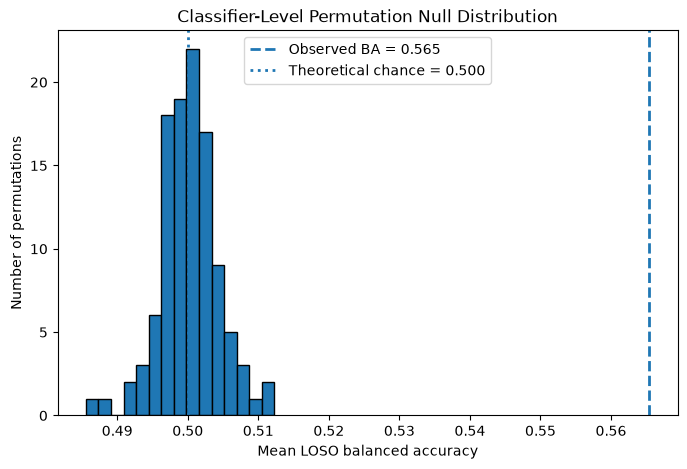

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    permutation_scores,
    bins=15,
    edgecolor="black"
)

plt.axvline(
    real_score,
    linestyle="--",
    linewidth=2,
    label=f"Observed BA = {real_score:.3f}"
)

plt.axvline(
    0.5,
    linestyle=":",
    linewidth=2,
    label="Theoretical chance = 0.500"
)

plt.xlabel("Mean LOSO balanced accuracy")
plt.ylabel("Number of permutations")
plt.title("Classifier-Level Permutation Null Distribution")
plt.legend()

plt.show()

### Classifier-Level Permutation Result

The fixed cross-subject CSP + LDA pipeline achieved an observed mean
LOSO balanced accuracy of 0.5654.

Across 109 restricted label permutations, the mean null balanced
accuracy was 0.5001, closely matching the theoretical chance level of
0.50.

None of the 109 permutation scores equaled or exceeded the observed
real-label performance.

Using the Monte Carlo permutation estimate, none of null scores were as large as the observed scores (Since we add +1 to the numerator). 

p = 1 / 110 = 0.0091.

The result therefore provides evidence that the observed cross-subject
decoding performance depends on genuine structure in the relationship
between the EEG signals and motor-imagery.

Mean balanced accuracy remained modest at approximately
0.565. It indicates that this modest above-chance performance
contains statistically detectable class information.

## Flagged subjects

The dataset by Shuqfa, Lakas & Belkacem written in the Week 4 reading notes flagged six subjects. 

We want to now analyze how they affected the analysis by inspecting then individually, comparing them to other subjects and checking for big changes across models. 

### Define and inspect flagged subjects in held-out analysis

In [28]:
flagged_subjects = [88, 89, 92, 100, 104, 106]

results["flagged"] = results["subject"].isin(flagged_subjects)

results.loc[
    results["flagged"],
    [
        "subject",
        "within_subject_ba",
        "fixed_cross_subject_ba",
        "tuned_cross_subject_ba",
        "within_to_fixed_diff",
        "fixed_to_tuned_diff"
    ]
]

,subject,within_subject_ba,fixed_cross_subject_ba,tuned_cross_subject_ba,within_to_fixed_diff,fixed_to_tuned_diff
87,88,0.490741,0.474754,0.383005,-0.015987,-0.091749
88,89,0.568452,0.488095,0.529762,-0.080357,0.041667
91,92,0.681481,0.616667,0.600000,-0.064815,-0.016667
99,100,0.416667,0.472222,0.472222,0.055556,0.000000
103,104,0.641865,0.428571,0.428571,-0.213294,0.000000
105,106,0.604167,0.541667,0.583333,-0.062500,0.041667


### Compare all subjects vs unflagged subjects

In [31]:

analysis_columns = [
    "within_subject_ba",
    "fixed_cross_subject_ba",
    "tuned_cross_subject_ba",
    "within_to_fixed_diff",
    "fixed_to_tuned_diff"
]

sensitivity_summary = pd.DataFrame({
    "all_subjects": results[analysis_columns].mean(),
    "excluding_flagged": results.loc[
        ~results["flagged"],
        analysis_columns
    ].mean()
})

sensitivity_summary["change"] = (
    sensitivity_summary["excluding_flagged"]
    - sensitivity_summary["all_subjects"]
)

sensitivity_summary

,all_subjects,excluding_flagged,change
within_subject_ba,0.597300,0.599052,0.001752
fixed_cross_subject_ba,0.565447,0.569047,0.003599
tuned_cross_subject_ba,0.575309,0.579726,0.004417
within_to_fixed_diff,-0.031853,-0.030006,0.001847
fixed_to_tuned_diff,0.009861,0.010679,0.000818


The classical model are not significantly defined by irregular subjects. We can see that only subject 104 was considerably worse after tuning. 

## Failure analysis

### Examine largest subject-level changes in within/cross

In [32]:
largest_cross_subject_drops = results.nsmallest(
    10,
    "within_to_fixed_diff"
)[
    [
        "subject",
        "within_subject_ba",
        "fixed_cross_subject_ba",
        "within_to_fixed_diff"
    ]
]

largest_cross_subject_drops

,subject,within_subject_ba,fixed_cross_subject_ba,within_to_fixed_diff
6,7,0.979167,0.615613,-0.363554
93,94,0.880952,0.522727,-0.358225
59,60,0.860119,0.564229,-0.295890
97,98,0.687500,0.425889,-0.261611
24,25,0.717262,0.477273,-0.239989
55,56,0.845238,0.620553,-0.224685
52,53,0.842262,0.621542,-0.220720
103,104,0.641865,0.428571,-0.213294
79,80,0.711310,0.506917,-0.204393
92,93,0.821429,0.629447,-0.191982


### Examine larger differences in fixed/tuned cross

In [33]:
largest_tuning_changes = (
    results
    .assign(
        absolute_change=results["fixed_to_tuned_diff"].abs()
    )
    .nlargest(10, "absolute_change")
    [
        [
            "subject",
            "fixed_cross_subject_ba",
            "tuned_cross_subject_ba",
            "fixed_to_tuned_diff"
        ]
    ]
)

largest_tuning_changes

,subject,fixed_cross_subject_ba,tuned_cross_subject_ba,fixed_to_tuned_diff
6,7,0.615613,0.911067,0.295455
69,70,0.541502,0.825099,0.283597
95,96,0.652174,0.415020,-0.237154
42,43,0.541502,0.754941,0.213439
85,86,0.500000,0.707510,0.207510
94,95,0.495059,0.644269,0.149209
24,25,0.477273,0.622530,0.145257
41,42,0.803360,0.673913,-0.129447
47,48,0.500000,0.626482,0.126482
102,103,0.569170,0.692688,0.123518


## Week 8 Summary — Statistical Validation and Robustness

Week 8 focused on determining how reliable and statistically defensible the classical EEG decoding results from Weeks 5–7 were.

### Performance uncertainty

Subject-level bootstrap confidence intervals were calculated for the three main classical experiments:

- Within-subject CSP + LDA:
  - Mean BA = 0.5973
  - 95% CI = [0.5739, 0.6242]

- Fixed cross-subject CSP + LDA:
  - Mean BA = 0.5654
  - 95% CI = [0.5476, 0.5869]

- Nested-tuned cross-subject CSP + LDA:
  - Mean BA = 0.5753
  - 95% CI = [0.5544, 0.5991]

The within-subject model had the highest average performance, while cross-subject decoding remained weaker and more difficult.

### Within-subject vs cross-subject generalization

The transition from within-subject to fixed cross-subject decoding produced:

- Mean difference = -0.0319
- 95% bootstrap CI = [-0.0541, -0.0097]
- Paired permutation p = 0.0044

A reduction of approximately 3.2 balanced-accuracy percentage points when moving from subject-dependent to unseen-subject evaluation is seen as statistically significant.

The result supports the conclusion that subject-specific information contributes meaningfully to EEG motor-imagery decoding and that generalization to unseen individuals is substantially harder.

### Effect of nested hyperparameter tuning

Comparing the fixed and nested-tuned cross-subject models produced:

- Mean difference = +0.0099
- 95% bootstrap CI = [-0.0029, 0.0246]
- Paired permutation p = 0.1582

Nested CSP hyperparameter tuning therefore increased mean balanced accuracy by approximately one percentage point, but the improvement was not statistically supported.

Hyperparameter tuning did not provide convincing evidence of systematic improvement across subjects.

### Classifier-level chance analysis

A restricted label-permutation test was performed on the fixed cross-subject CSP + LDA pipeline.

Only left/right motor-imagery labels were permuted within subject/run blocks.

Results:

- Observed mean LOSO BA = 0.5654
- Mean null BA = 0.5001
- Number of permutations = 109
- Monte Carlo permutation p = 0.0091

None of the shuffled-label datasets achieved performance equal to or greater than the real-label result.

This provides evidence that the observed cross-subject decoding performance depends on genuine structure in the relationship between EEG activity and motor-imagery labels.

However, statistically detectable above-chance performance should not be confused with strong predictive performance.

### Robustness to predefined irregular subjects

Six subjects had previously been flagged because of technical or recording irregularities:

88, 89, 92, 100, 104, and 106.

The main results were recalculated after excluding these subjects from the held-out cohort summaries.

Changes were small:

- Within-subject mean BA:
  - 0.5973 → 0.5991
  - Change = +0.0018

- Fixed cross-subject mean BA:
  - 0.5654 → 0.5690
  - Change = +0.0036

- Tuned cross-subject mean BA:
  - 0.5753 → 0.5797
  - Change = +0.0044

- Within → fixed mean difference:
  - -0.0319 → -0.0300

- Fixed → tuned mean difference:
  - +0.0099 → +0.0107

The main conclusions therefore remained essentially unchanged after removing the flagged subjects from the evaluation summaries.

The largest within-subject to cross-subject performance drops were also not concentrated among the flagged subjects.

This suggests that the poor cross-subject transfer is a broader feature of EEG generalization.

This sensitivity analysis only removed flagged subjects from the held-out summary statistics. It did not retrain every LOSO model with the flagged subjects removed from the training population.

### Overall Week 8 conclusion

The classical phase produced three main findings.

First, motor-imagery EEG contains statistically detectable information that generalizes across subjects, as demonstrated by the classifier-level permutation test.

Second, cross-subject generalization is meaningfully harder than within-subject decoding, with an average performance reduction of approximately 3.2 balanced-accuracy percentage points.

Third, nested CSP hyperparameter tuning produced only a small average improvement and did not provide convincing evidence of systematic benefit.

The results were robust to the predefined technically irregular subjects and showed substantial inter-subject heterogeneity.

The classical CSP + LDA pipeline can therefore now be treated as a benchmark for comparison with the upcoming deep-learning models.